## Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler

## Data Loading and Plotting

In [28]:
# training_set = pd.read_csv('airline-passengers.csv')
#training_set = pd.read_csv('shampoo.csv')
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
training_set = pd.read_csv(url) #, parse_dates=['Month'], index_col='Month')

training_set.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [6]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [33]:
training_set.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


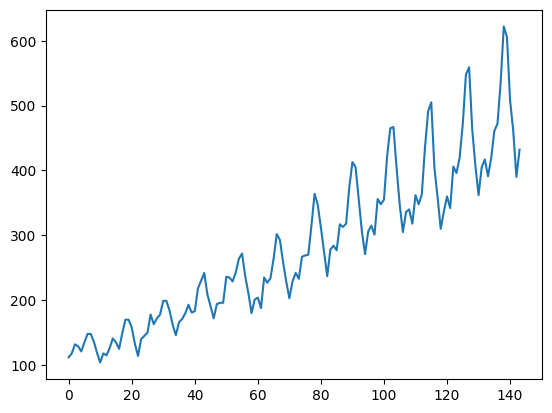

In [29]:
training_set = training_set.iloc[:,1:2].values

plt.plot(training_set, label = 'Data')
plt.show()

## Dataloading

In [30]:
def scaling_window(data, seq_length):
    x = []
    y = []

    for i in range(len(data)-seq_length-1):
        _x = data[i:(i+seq_length)]
        _y = data[i+seq_length]
        x.append(_x)
        y.append(_y)

    return np.array(x),np.array(y)

sc = MinMaxScaler()
training_data = sc.fit_transform(training_set)

seq_length = 30
x, y = scaling_window(training_data, seq_length)

train_size = int(len(y) * 0.67)
test_size = len(y) - train_size

dataX = Variable(torch.Tensor(np.array(x)))
dataY = Variable(torch.Tensor(np.array(y)))

trainX = Variable(torch.Tensor(np.array(x[0:train_size])))
trainY = Variable(torch.Tensor(np.array(y[0:train_size])))

testX = Variable(torch.Tensor(np.array(x[train_size:len(x)])))
testY = Variable(torch.Tensor(np.array(y[train_size:len(y)])))

In [58]:
len(x)

113

## Model

In [31]:
class LSTM(nn.Module):

    def __init__(self, num_classes, input_size, hidden_size, num_layers):
        super(LSTM, self).__init__()
        
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.seq_length = seq_length
        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size))
        c_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size))
        
        # Propagate input through LSTM
        ula, (h_out, _) = self.lstm(x, (h_0, c_0))
        h_out = h_out.view(-1, self.hidden_size)
        out = self.fc(h_out)
        
        return out

## Training

In [15]:
trainX.shape

torch.Size([75, 30, 1])

In [50]:
    from sklearn.model_selection import train_test_split
    from torch.utils.data import TensorDataset
    
    def create_dataset(data, window_size=1):
        X, Y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i:(i + window_size)])
            Y.append(data[i + window_size])
        return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)
    
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
    data = pd.read_csv(url)
    data = data.iloc[:,1:2].values

    # Scale the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Define the window size
    window_size = 30

    # Create the dataset
    X, Y = create_dataset(data, window_size)

    # Split the data into training and test sets
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

    # Create TensorDataset for training and testing
    train_dataset = TensorDataset(X_train, Y_train)
    test_dataset = TensorDataset(X_test, Y_test)

In [51]:
# train_dataset = torch.load(f'datasets/{"airline"}_train.pt', weights_only=False)
# test_dataset = torch.load(f'datasets/{"airline"}_test.pt', weights_only=False)
# take the features and labels from the datasets
trainX, trainY = train_dataset.tensors
trainX = trainX
testX, testY = test_dataset.tensors
testX = testX

In [25]:
trainX.shape

torch.Size([91, 30, 1])

In [56]:
num_epochs = 1000
learning_rate = 0.01

input_size = 1
hidden_size = 2
num_layers = 1

num_classes = 1

lstm = LSTM(num_classes, input_size, hidden_size, num_layers)

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate)
#optimizer = torch.optim.SGD(lstm.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    outputs = lstm(trainX)
    optimizer.zero_grad()
    
    # obtain the loss function
    loss = criterion(outputs, trainY)
    
    loss.backward()
    
    optimizer.step()
    if epoch % 100 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.71330
Epoch: 100, loss: 0.01995
Epoch: 200, loss: 0.01362
Epoch: 300, loss: 0.00727
Epoch: 400, loss: 0.00564
Epoch: 500, loss: 0.00539
Epoch: 600, loss: 0.00511
Epoch: 700, loss: 0.00479
Epoch: 800, loss: 0.00444
Epoch: 900, loss: 0.00406


In [57]:
test_predict = lstm(trainX)
test_predict = test_predict.data.numpy()
testY = trainY.data.numpy()

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(testY, test_predict)
r2 = r2_score(testY, test_predict)
print("MSE: %1.5f" % mse)
print("R2: %1.5f" % r2)

MSE: 0.00369
R2: 0.85293


In [ ]:
def evaluate_test(model, test_loader, device='cpu'):
    model.eval()
    actuals, predictions = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)
                predictions.append(outputs.cpu().numpy().flatten())
                actuals.append(labels.cpu().numpy().flatten())
            elif model.task_type == 'classification':
                labels = labels.long()
                predictions.append(outputs.cpu().numpy())
                actuals.append(labels.cpu().numpy())

    predictions = np.concatenate(predictions)
    actuals = np.concatenate(actuals)
    
    if model.task_type == 'regression':
        # Calculate regression metrics
        mse = mean_squared_error(actuals, predictions)
        r2 = r2_score(actuals, predictions)
        
        print(f' - Mean Squared Error: {mse:.4f}')
        print(f' - R² Score: {r2:.4f}')
        
        return mse, r2

## Testing for Shampoo Sales Dataset

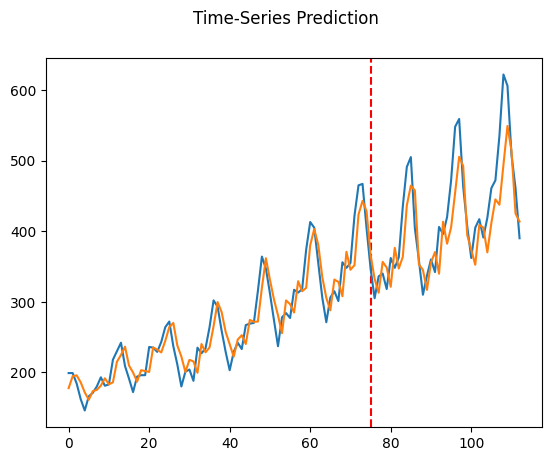

In [13]:
lstm.eval()
train_predict = lstm(dataX)

data_predict = train_predict.data.numpy()
dataY_plot = dataY.data.numpy()

data_predict = sc.inverse_transform(data_predict)
dataY_plot = sc.inverse_transform(dataY_plot)

plt.axvline(x=train_size, c='r', linestyle='--')

plt.plot(dataY_plot)
plt.plot(data_predict)
plt.suptitle('Time-Series Prediction')
plt.show()

## Testing for Airplane Passengers Dataset

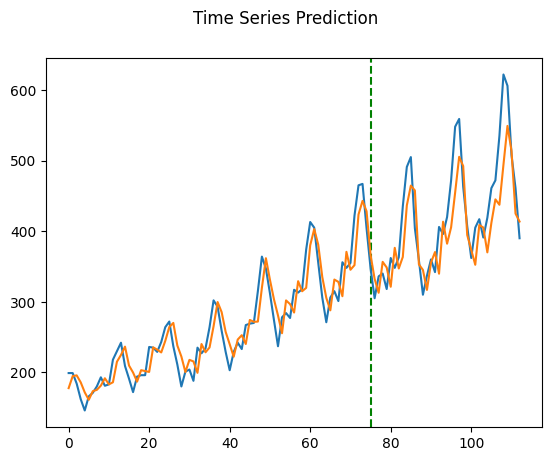

In [14]:
lstm.eval()
train_predict = lstm(dataX)

data_predict = train_predict.data.numpy()
dataY_plot = dataY.data.numpy()

data_predict = sc.inverse_transform(data_predict)
dataY_plot = sc.inverse_transform(dataY_plot)

plt.axvline(x=train_size, c='g', linestyle='--')

plt.plot(dataY_plot)
plt.plot(data_predict)
plt.suptitle('Time Series Prediction')
plt.show()